# §0 — Setup, Imports y Logging

En esta sección importamos todas las librerías necesarias y configuramos el sistema de logging que nos permitirá monitorear el progreso de la ejecución en tiempo real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import json
import sys
from datetime import datetime, timedelta

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, make_scorer
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración visual
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Seed para reproducibilidad
SEED = 42
np.random.seed(SEED)

# =====================================================
#   CONFIGURACIÓN DE LOGGING (JUPYTER-SAFE)
# =====================================================

LOG_DIR = 'logs'
os.makedirs(LOG_DIR, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
LOG_FILE = os.path.join(LOG_DIR, f'notebook06_execution_{timestamp}.log')
METRICS_FILE = os.path.join(LOG_DIR, f'notebook06_metrics_{timestamp}.json')

class JupyterSafeLogger:
    """Logger que funciona en Jupyter sin problemas de encoding en Windows"""
    
    def __init__(self, log_file):
        self.log_file = log_file
        self.file_handler = open(log_file, 'w', encoding='utf-8')
    
    def info(self, message):
        """Log a archivo (UTF-8) y a consola (ASCII-safe)"""
        # Escribir a archivo con UTF-8
        self.file_handler.write(message + '\n')
        self.file_handler.flush()
        
        # Escribir a consola reemplazando caracteres problemáticos
        safe_message = self._make_safe(message)
        try:
            print(safe_message)
        except UnicodeEncodeError:
            # Si aún falla, intenta con caracteres ASCII puros
            safe_message = safe_message.encode('ascii', 'replace').decode('ascii')
            print(safe_message)
    
    def error(self, message):
        """Log de error"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        full_msg = f'[{timestamp}] [ERROR  ] {message}'
        
        self.file_handler.write(full_msg + '\n')
        self.file_handler.flush()
        
        safe_message = self._make_safe(full_msg)
        try:
            print(safe_message)
        except:
            pass
    
    def warning(self, message):
        """Log de warning"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        full_msg = f'[{timestamp}] [WARNING] {message}'
        
        self.file_handler.write(full_msg + '\n')
        self.file_handler.flush()
        
        safe_message = self._make_safe(full_msg)
        try:
            print(safe_message)
        except:
            pass
    
    @staticmethod
    def _make_safe(message):
        """Reemplaza caracteres problemáticos por ASCII-safe"""
        replacements = {
            '█': '=',
            '▶': '>',
            '─': '-',
            '═': '=',
            '«': '<',
            '»': '>',
            '•': '*',
        }
        
        for char, replacement in replacements.items():
            message = message.replace(char, replacement)
        
        return message
    
    def close(self):
        """Cerrar archivo de log"""
        self.file_handler.close()

# Crear logger
logger = JupyterSafeLogger(LOG_FILE)

# Print header
print("\n" + "="*70)
print("="*5 + "  NOTEBOOK 06 - MODELADO RIGUROSO v4 (MEJORADO)  " + "="*5)
print("="*70)
logger.info("")
logger.info("="*70)
logger.info("="*5 + "  NOTEBOOK 06 - MODELADO RIGUROSO v4 (MEJORADO)  " + "="*5)
logger.info("="*70)
logger.info(f"Log file: {LOG_FILE}")
logger.info(f"Metrics file: {METRICS_FILE}")
logger.info("="*70)
logger.info("")

# Diccionario para guardar métricas
EXECUTION_METRICS = {
    'timestamp_start': datetime.now().isoformat(),
    'timestamp_end': None,
    'duration_seconds': None,
    'checkpoints': {
        'CP1': {'status': 'pending', 'start': None, 'end': None, 'duration': None},
        'CP2': {'status': 'pending', 'start': None, 'end': None, 'duration': None},
    },
    'models_executed': [],
    'total_gridsearches': 0,
    'errors': [],
}

ALL_RESULTS = []  # Acumulador global de resultados


=====  NOTEBOOK 06 - MODELADO RIGUROSO v4 (MEJORADO)  =====

=====  NOTEBOOK 06 - MODELADO RIGUROSO v4 (MEJORADO)  =====
Log file: logs\notebook06_execution_20260310_133444.log
Metrics file: logs\notebook06_metrics_20260310_133444.json



# §1 — Carga y Preparación de Datos

Cargamos el dataset completo y filtramos solo a los estudiantes activos (APROBÓ o REPROBÓ). Excluimos a los retirados porque sus datos no son comparables (tienen ceros en engagement pero no aprendieron nada).

In [2]:
logger.info("")
logger.info("="*70)
logger.info("  CARGA Y FILTRADO DE DATOS")
logger.info("="*70)
logger.info("")

# Cargar datos
DATA_PATH = os.path.join('..', 'data', 'dataset_completo_final.csv')
df_all = pd.read_csv(DATA_PATH)

logger.info(f"Dataset cargado: {df_all.shape[0]} filas x {df_all.shape[1]} columnas")
logger.info(f"")
logger.info(f"Distribucion inicial de estados:")
for estado, count in df_all['estado'].value_counts().items():
    pct = (count / len(df_all)) * 100
    logger.info(f"  {estado:>10s}: {count:>3d} ({pct:>5.1f}%)")

# PASO 1: Filtrar APROBÓ + REPROBÓ (excluir RETIRADO, SIN_NOTA)
df_active = df_all[df_all['estado'].isin(['APROBÓ', 'REPROBÓ'])].copy()

logger.info(f"")
logger.info(f"-"*70)
logger.info(f"Paso 1 - Filtrar estudiantes activos (APROBÓ + REPROBÓ):")
logger.info(f"  Estudiantes activos: {len(df_active)}")
logger.info(f"    APROBÓ:  {(df_active['estado']=='APROBÓ').sum()}")
logger.info(f"    REPROBÓ: {(df_active['estado']=='REPROBÓ').sum()}")

# PASO 2: Filtrar SOLO los que tienen engagement (datos de plataforma)
df_with_engagement = df_active[
    (df_active['engagement_hasta_p1'] > 0) | 
    (df_active['parcial_1_visitas'] > 0) | 
    (df_active['parcial_1_tiempo_hrs'] > 0)
].copy()

removed_no_engagement = len(df_active) - len(df_with_engagement)

logger.info(f"")
logger.info(f"-"*70)
logger.info(f"Paso 2 - Filtrar SOLO estudiantes CON engagement:")
logger.info(f"  Estudiantes con engagement: {len(df_with_engagement)}")
logger.info(f"  Estudiantes sin engagement: {removed_no_engagement}")
logger.info(f"  Porcentaje removido: {(removed_no_engagement/len(df_active)*100):.1f}%")

if removed_no_engagement > 0:
    logger.info(f"")
    logger.info(f"  Criterios de inclusion:")
    logger.info(f"    - engagement_hasta_p1 > 0 (horas en plataforma)")
    logger.info(f"    O parcial_1_visitas > 0 (visitas al contenido)")
    logger.info(f"    O parcial_1_tiempo_hrs > 0 (tiempo dedicado)")
    logger.info(f"")
    logger.info(f"  Razon de exclusion:")
    logger.info(f"    - Estudiantes con cero engagement en TODOS los indicadores")
    logger.info(f"    - Sus datos de comportamiento digital son incompletos")

# PASO 3: Crear variables target
df = df_with_engagement.copy()
df['target'] = (df['estado'] == 'REPROBÓ').astype(int)
df['era_encoded'] = (df['era'] == 'formato_nuevo').astype(int)

logger.info(f"")
logger.info(f"-"*70)
logger.info(f"DATOS FINALES PARA MODELADO:")
logger.info(f"  Total estudiantes: {len(df)}")
logger.info(f"  Distribucion:")
logger.info(f"    APROBÓ (target=0):  {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
logger.info(f"    REPROBÓ (target=1): {(df['target']==1).sum()} ({(df['target']==1).mean()*100:.1f}%)")
logger.info(f"  Ratio APROBÓ:REPROBÓ: {(df['target']==0).sum() / (df['target']==1).sum():.2f}:1")

logger.info(f"")
logger.info(f"-"*70)
logger.info(f"RESUMEN FILTRADO:")
logger.info(f"  Dataset original:      {len(df_all)} estudiantes")
logger.info(f"    - RETIRADO/SIN_NOTA: {len(df_all) - len(df_active)}")
logger.info(f"    - Sin engagement:    {removed_no_engagement}")
logger.info(f"  = Datos validos:       {len(df)} estudiantes ({len(df)/len(df_all)*100:.1f}%)")
logger.info(f"")
logger.info(f"Estos {len(df)} estudiantes tienen:")
logger.info(f"  - Estado academico completo (APROBÓ o REPROBÓ)")
logger.info(f"  - Datos de engagement en Bloque Neon")
logger.info(f"  - Informacion util para prediccion")
logger.info(f"")


  CARGA Y FILTRADO DE DATOS

Dataset cargado: 764 filas x 77 columnas

Distribucion inicial de estados:
      APROBÓ: 413 ( 54.1%)
    RETIRADO: 164 ( 21.5%)
     REPROBÓ: 141 ( 18.5%)
    SIN_NOTA:  46 (  6.0%)

----------------------------------------------------------------------
Paso 1 - Filtrar estudiantes activos (APROBÓ + REPROBÓ):
  Estudiantes activos: 554
    APROBÓ:  413
    REPROBÓ: 141

----------------------------------------------------------------------
Paso 2 - Filtrar SOLO estudiantes CON engagement:
  Estudiantes con engagement: 504
  Estudiantes sin engagement: 50
  Porcentaje removido: 9.0%

  Criterios de inclusion:
    - engagement_hasta_p1 > 0 (horas en plataforma)
    O parcial_1_visitas > 0 (visitas al contenido)
    O parcial_1_tiempo_hrs > 0 (tiempo dedicado)

  Razon de exclusion:
    - Estudiantes con cero engagement en TODOS los indicadores
    - Sus datos de comportamiento digital son incompletos

--------------------------------------------------------

# §2 — Definición de Features por Checkpoint

Seleccionamos features para CP1 (Semana 6) y CP2 (Semana 11).

In [3]:
logger.info("="*70)
logger.info("  DEFINICIÓN DE FEATURES")
logger.info("="*70)
logger.info("")

# === CHECKPOINT 1 (Semana 6 — Post Parcial 1) ===

# ✅ OPTIMIZADAS (5 features):
FEATURES_CP1 = [
    'parcial_1',
    'engagement_hasta_p1',
    'parcial_1_modulos_unicos',
    'parcial_1_visitas_por_tema',
    'parcial_1_tiempo_por_visita',
    'era_encoded',
]

FEATURES_CP2 = [
    'parcial_1', 'parcial_2', 'parcial_3',
    'promedio_ams', 'promedio_quices',
    'engagement_hasta_p1', 'parcial_1_modulos_unicos',
    'parcial_1_visitas', 'parcial_1_temas_unicos',
    'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita',
    'era_encoded',
]

logger.info(f"CHECKPOINT 1 (Semana 6): {len(FEATURES_CP1)} features")
logger.info(f"-"*70)
for i, f in enumerate(FEATURES_CP1, 1):
    logger.info(f"  {i:2d}. {f}")

logger.info(f"")
logger.info(f"CHECKPOINT 2 (Semana 11): {len(FEATURES_CP2)} features")
logger.info(f"-"*70)
for i, f in enumerate(FEATURES_CP2, 1):
    logger.info(f"  {i:2d}. {f}")

logger.info(f"")

  DEFINICIÓN DE FEATURES

CHECKPOINT 1 (Semana 6): 6 features
----------------------------------------------------------------------
   1. parcial_1
   2. engagement_hasta_p1
   3. parcial_1_modulos_unicos
   4. parcial_1_visitas_por_tema
   5. parcial_1_tiempo_por_visita
   6. era_encoded

CHECKPOINT 2 (Semana 11): 12 features
----------------------------------------------------------------------
   1. parcial_1
   2. parcial_2
   3. parcial_3
   4. promedio_ams
   5. promedio_quices
   6. engagement_hasta_p1
   7. parcial_1_modulos_unicos
   8. parcial_1_visitas
   9. parcial_1_temas_unicos
  10. parcial_1_visitas_por_tema
  11. parcial_1_tiempo_por_visita
  12. era_encoded



# §3 — Preparación de Datos

Preparamos matrices X e y para cada checkpoint.

In [4]:
def prepare_data(df, features, checkpoint_name):
    """
    Preparar X, y con imputación y reporte de missingness.
    
    Parámetros:
        df: DataFrame con todos los datos
        features: lista de nombres de features a usar
        checkpoint_name: 'CP1' o 'CP2' (para logging)
    
    Retorna:
        X: matriz de features (n_samples x n_features)
        y: vector de target (n_samples,)
    """
    X = df[features].copy()
    y = df['target'].copy()
    
    # Reporte de missingness ANTES de imputar
    missing = X.isnull().sum()
    missing_pct = (X.isnull().sum() / len(X) * 100)
    
    if missing.sum() > 0:
        logger.info(f"Valores faltantes en {checkpoint_name} (antes de imputar):")
        for col in missing[missing > 0].index:
            logger.info(f"  {col}: {missing[col]} ({missing_pct[col]:.1f}%)")
    
    # Imputar con 0
    X = X.fillna(0)
    
    logger.info(f"Datos listos para {checkpoint_name}:")
    logger.info(f"  X: {X.shape[0]} muestras x {X.shape[1]} features")
    logger.info(f"  y: APROBÓ={int((y==0).sum())}, REPROBÓ={int((y==1).sum())}")
    
    return X, y

logger.info("="*70)
logger.info("  PREPARACIÓN DE MATRICES X, y")
logger.info("="*70)
logger.info("")

X_cp1, y_cp1 = prepare_data(df, FEATURES_CP1, "CP1")
logger.info("")
X_cp2, y_cp2 = prepare_data(df, FEATURES_CP2, "CP2")
logger.info("")

  PREPARACIÓN DE MATRICES X, y

Datos listos para CP1:
  X: 504 muestras x 6 features
  y: APROBÓ=374, REPROBÓ=130

Valores faltantes en CP2 (antes de imputar):
  promedio_quices: 179 (35.5%)
Datos listos para CP2:
  X: 504 muestras x 12 features
  y: APROBÓ=374, REPROBÓ=130



# §4 — Definición de Modelos e Hiperparámetros (MEJORADOS)

Aquí definimos los 5 modelos y sus espacios de búsqueda REDUCIDOS.

In [5]:
logger.info("="*70)
logger.info("  DEFINICIÓN DE MODELOS E HIPERPARÁMETROS")
logger.info("="*70)
logger.info("")

MODELS_AND_GRIDS = {
    'Logistic Regression (L1-Lasso)': {
        'model': LogisticRegression(
            penalty='l1', solver='liblinear', random_state=SEED, max_iter=5000
        ),
        'params': {
            'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        },
        'description': 'Regresion logistica con penalizacion L1 (Lasso). '
                       'Selecciona automaticamente variables relevantes.'
    },
    'Logistic Regression (L2-Ridge)': {
        'model': LogisticRegression(
            penalty='l2', solver='liblinear', random_state=SEED, max_iter=5000
        ),
        'params': {
            'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        },
        'description': 'Regresion logistica con penalizacion L2 (Ridge). '
                       'Encoge coeficientes sin eliminarlos.'
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=SEED),
        'params': {
            'clf__max_depth': [3, 5, 7, 10, 15],
            'clf__min_samples_leaf': [2, 5, 10],
            'clf__min_samples_split': [5, 10],
            'clf__criterion': ['gini', 'entropy'],
            'clf__ccp_alpha': [0.0, 0.005, 0.01],
        },
        'description': 'Arbol de decision con poda. Muy interpretable.'
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'params': {
            'clf__n_estimators': [100, 300, 500],
            'clf__max_depth': [5, 10, 15],
            'clf__min_samples_leaf': [2, 5],
            'clf__min_samples_split': [5, 10],
            'clf__max_features': ['sqrt', 'log2'],
        },
        'description': 'Bosque aleatorio. Robusto y eficiente.'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'clf__n_estimators': [100, 300, 500],
            'clf__max_depth': [3, 5, 7],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__min_samples_leaf': [2, 5],
            'clf__subsample': [0.7, 0.9, 1.0],
        },
        'description': 'Gradient Boosting. Generalmente el mas preciso.'
    },
}

# Contar combinaciones y mostrar
logger.info("MALLAS DE BÚSQUEDA POR MODELO:")
logger.info("")

total_per_scenario = 0

for name, cfg in MODELS_AND_GRIDS.items():
    n_combos = int(np.prod([len(v) for v in cfg['params'].values()]))
    n_fits = n_combos * 5  # 5 folds
    total_per_scenario += n_fits
    
    logger.info(f">>> {name}")
    logger.info(f"  Combinaciones: {n_combos}")
    logger.info(f"  Fits (5-Fold CV): {n_fits}")
    logger.info(f"  Tiempo estimado: {(n_fits * 0.5 / 60):.1f} min")
    logger.info(f"")

logger.info("-"*70)
logger.info(f"TOTAL por escenario de balanceo:")
logger.info(f"  Fits: {total_per_scenario}")
logger.info(f"  Tiempo por balanceo: {(total_per_scenario * 0.5 / 60):.1f} min")
logger.info(f"  Tiempo total (3 balanceos): {(total_per_scenario * 0.5 * 3 / 60):.1f} min = {(total_per_scenario * 0.5 * 3 / 3600):.2f} horas")
logger.info("")

  DEFINICIÓN DE MODELOS E HIPERPARÁMETROS

MALLAS DE BÚSQUEDA POR MODELO:

>>> Logistic Regression (L1-Lasso)
  Combinaciones: 6
  Fits (5-Fold CV): 30
  Tiempo estimado: 0.2 min

>>> Logistic Regression (L2-Ridge)
  Combinaciones: 6
  Fits (5-Fold CV): 30
  Tiempo estimado: 0.2 min

>>> Decision Tree
  Combinaciones: 180
  Fits (5-Fold CV): 900
  Tiempo estimado: 7.5 min

>>> Random Forest
  Combinaciones: 72
  Fits (5-Fold CV): 360
  Tiempo estimado: 3.0 min

>>> Gradient Boosting
  Combinaciones: 162
  Fits (5-Fold CV): 810
  Tiempo estimado: 6.8 min

----------------------------------------------------------------------
TOTAL por escenario de balanceo:
  Fits: 2130
  Tiempo por balanceo: 17.8 min
  Tiempo total (3 balanceos): 53.2 min = 0.89 horas



# §4B — Mostrar TODOS los Parámetros por Modelo (DETALLADO)

Muestra qué parámetros se van a probar en cada modelo.

In [6]:
logger.info("="*70)
logger.info("  DETALLE COMPLETO: PARÁMETROS A PROBAR")
logger.info("="*70)
logger.info("")

for model_name, cfg in MODELS_AND_GRIDS.items():
    n_combos = int(np.prod([len(v) for v in cfg['params'].values()]))
    n_fits = n_combos * 5
    
    logger.info(f"")
    logger.info(f">"*35)
    logger.info(f"MODELO: {model_name}")
    logger.info(f">"*35)
    logger.info(f"Descripcion: {cfg['description']}")
    logger.info(f"")
    
    logger.info(f"Parametros a explorar:")
    for param_name, values in cfg['params'].items():
        clean_name = param_name.replace('clf__', '')
        logger.info(f"  {clean_name}:")
        logger.info(f"    Valores: {values}")
        logger.info(f"    Cantidad: {len(values)}")
        logger.info(f"")
    
    logger.info(f"Estadisticas de busqueda:")
    logger.info(f"  Total combinaciones: {n_combos:,}")
    logger.info(f"  Folds CV: 5")
    logger.info(f"  Total ajustes: {n_fits:,}")
    logger.info(f"  Tiempo estimado: {(n_fits * 0.5 / 60):.1f} minutos")
    logger.info(f"")
    logger.info(f"-"*70)

logger.info("")

  DETALLE COMPLETO: PARÁMETROS A PROBAR


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
MODELO: Logistic Regression (L1-Lasso)
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Descripcion: Regresion logistica con penalizacion L1 (Lasso). Selecciona automaticamente variables relevantes.

Parametros a explorar:
  C:
    Valores: [0.001, 0.01, 0.1, 1, 10, 100]
    Cantidad: 6

Estadisticas de busqueda:
  Total combinaciones: 6
  Folds CV: 5
  Total ajustes: 30
  Tiempo estimado: 0.2 minutos

----------------------------------------------------------------------

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
MODELO: Logistic Regression (L2-Ridge)
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Descripcion: Regresion logistica con penalizacion L2 (Ridge). Encoge coeficientes sin eliminarlos.

Parametros a explorar:
  C:
    Valores: [0.001, 0.01, 0.1, 1, 10, 100]
    Cantidad: 6

Estadisticas de busqueda:
  Total combinaciones: 6
  Folds CV: 5
  Total ajustes: 30
  Tiempo estimado: 0.2 minutos

----------------------------------------

# §5 — Funciones Auxiliares

Funciones reutilizables para ejecutar gridsearch y guardar resultados.

In [7]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def guardar_resultados_checkpoint(checkpoint, balanceo, resultados):
    """Guardar resultados después de cada ronda de balanceo."""
    if not resultados:
        logger.warning(f"No results to save for {checkpoint} {balanceo}")
        return None
    
    df_checkpoint = pd.DataFrame([r['result'] for r in resultados])
    filename = os.path.join(LOG_DIR, f'{checkpoint}_{balanceo.lower()}_results.csv')
    df_checkpoint.to_csv(filename, index=False, encoding='utf-8-sig')
    
    logger.info(f"")
    logger.info(f"-"*70)
    logger.info(f"Checkpoint guardado: {filename}")
    logger.info(f"  {len(resultados)} modelos registrados")
    logger.info(f"  Mejor AUC: {df_checkpoint['ROC_AUC_mean'].max():.4f}")
    logger.info(f"-"*70)
    logger.info(f"")
    
    return filename


def log_progress(current, total, elapsed_time, checkpoint_name, balancing_name):
    """Loggear progreso con ETA."""
    progress_pct = (current / total) * 100
    avg_time = elapsed_time / current
    remaining_models = total - current
    estimated_remaining = avg_time * remaining_models
    
    logger.info(f"")
    logger.info(f"="*70)
    logger.info(f"PROGRESO: [{checkpoint_name}] [{balancing_name}]")
    logger.info(f"  Completado: {current}/{total} modelos ({progress_pct:.0f}%)")
    logger.info(f"  Tiempo transcurrido: {elapsed_time/60:.1f} min")
    logger.info(f"  Tiempo promedio/modelo: {avg_time:.1f}s")
    logger.info(f"  Tiempo estimado restante: {estimated_remaining/60:.1f} min")
    logger.info(f"  ETA: {(datetime.now() + timedelta(seconds=estimated_remaining)).strftime('%H:%M:%S')}")
    logger.info(f"="*70)
    logger.info(f"")


def validate_execution():
    """Validar datos antes de ejecutar."""
    logger.info(f"")
    logger.info(f"="*70)
    logger.info(f"VALIDACIÓN PRE-EJECUCIÓN")
    logger.info(f"="*70)
    logger.info(f"")
    
    # Validar dimensiones
    logger.info(f"Validacion de dimensiones:")
    logger.info(f"  X_cp1: {X_cp1.shape} OK")
    logger.info(f"  y_cp1: {y_cp1.shape} OK")
    logger.info(f"  X_cp2: {X_cp2.shape} OK")
    logger.info(f"  y_cp2: {y_cp2.shape} OK")
    logger.info(f"")
    
    # Validar no hay NaNs
    assert not X_cp1.isnull().any().any(), "X_cp1 has NaNs!"
    assert not X_cp2.isnull().any().any(), "X_cp2 has NaNs!"
    logger.info(f"No hay valores faltantes: OK")
    logger.info(f"")
    
    # Validar balance
    for X, y, name in [(X_cp1, y_cp1, 'CP1'), (X_cp2, y_cp2, 'CP2')]:
        balance = (y == 1).sum() / len(y)
        logger.info(f"  {name}: {balance:.1%} clase negativa (REPROBÓ) OK")
    logger.info(f"")
    
    # Validar features existen
    missing_features = set(FEATURES_CP1) - set(df.columns)
    if missing_features:
        logger.error(f"Missing features: {missing_features}")
        raise ValueError(f"Missing features: {missing_features}")
    
    logger.info(f"Todas las features estan presentes: OK")
    logger.info(f"")
    logger.info(f"Validacion completada. Listo para ejecutar.")
    logger.info(f"")

# Ejecutar validación
validate_execution()


VALIDACIÓN PRE-EJECUCIÓN

Validacion de dimensiones:
  X_cp1: (504, 6) OK
  y_cp1: (504,) OK
  X_cp2: (504, 12) OK
  y_cp2: (504,) OK

No hay valores faltantes: OK

  CP1: 25.8% clase negativa (REPROBÓ) OK
  CP2: 25.8% clase negativa (REPROBÓ) OK

Todas las features estan presentes: OK

Validacion completada. Listo para ejecutar.



# §6 — GridSearchCV con Logging Completo

Función principal que ejecuta búsqueda de hiperparámetros con logging detallado.

In [8]:
def run_gridsearch(X, y, model_name, model_config, balancing='Ninguno',
                   checkpoint='CP1', cv=CV):
    """
    Ejecuta GridSearchCV completo para un modelo con logging detallado.
    
    Parámetros:
        X, y: datos de entrada
        model_name: nombre del modelo
        model_config: dict con 'model', 'params', 'description'
        balancing: 'Ninguno', 'SMOTE', o 'SMOTEENN'
        checkpoint: 'CP1' o 'CP2'
        cv: estrategia de cross-validation
    
    Retorna:
        dict con resultados, modelo y grid
    """
    
    start_time = time.time()
    n_combos = int(np.prod([len(v) for v in model_config['params'].values()]))
    total_fits = n_combos * cv.n_splits
    
    # Logging inicial detallado
    logger.info(f"")
    logger.info(f"-"*70)
    logger.info(f"[{checkpoint}] {model_name} | Balanceo: {balancing}")
    logger.info(f"-"*70)
    logger.info(f"Tamano de grid: {n_combos} combinaciones x {cv.n_splits} folds = {total_fits} ajustes")
    logger.info(f"Datos: {X.shape[0]} muestras, {X.shape[1]} features")
    logger.info(f"Distribucion de clases: {dict(pd.Series(y).value_counts())}")
    logger.info(f"Hora inicio: {datetime.now().strftime('%H:%M:%S')}")
    logger.info(f"")
    
    # Construir pipeline según balanceo
    if balancing == 'SMOTE':
        pipe = ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', SMOTE(random_state=SEED)),
            ('clf', model_config['model'])
        ])
    elif balancing == 'SMOTEENN':
        pipe = ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', SMOTEENN(random_state=SEED)),
            ('clf', model_config['model'])
        ])
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model_config['model'])
        ])
    
    try:
        logger.info(f"Iniciando GridSearchCV...")
        logger.info(f"")
        
        # GridSearchCV CON VERBOSE=1
        grid = GridSearchCV(
            pipe, 
            model_config['params'],
            cv=cv, 
            scoring='roc_auc', 
            refit=True,
            n_jobs=-1, 
            verbose=1,
            return_train_score=True,
            error_score='raise'
        )
        
        grid.fit(X, y)
        elapsed = time.time() - start_time
        
        # Extraer mejores parámetros
        best_model = grid.best_estimator_
        
        # Cross-validate con múltiples métricas
        scoring = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score, zero_division=0),
            'f1': make_scorer(f1_score, zero_division=0),
            'roc_auc': 'roc_auc',
        }
        
        cv_results = cross_validate(
            best_model, X, y, cv=cv, scoring=scoring, return_train_score=False
        )
        
        result = {
            'Checkpoint': checkpoint,
            'Modelo': model_name,
            'Balanceo': balancing,
            'Accuracy_mean': cv_results['test_accuracy'].mean(),
            'Accuracy_std': cv_results['test_accuracy'].std(),
            'Precision_mean': cv_results['test_precision'].mean(),
            'Precision_std': cv_results['test_precision'].std(),
            'Recall_mean': cv_results['test_recall'].mean(),
            'Recall_std': cv_results['test_recall'].std(),
            'F1_mean': cv_results['test_f1'].mean(),
            'F1_std': cv_results['test_f1'].std(),
            'ROC_AUC_mean': cv_results['test_roc_auc'].mean(),
            'ROC_AUC_std': cv_results['test_roc_auc'].std(),
            'Best_Params': str(grid.best_params_),
            'GridSearch_Best_AUC': grid.best_score_,
            'N_Combinaciones': n_combos,
            'Tiempo_seg': round(elapsed, 1),
            'Descripcion': model_config['description'],
            'Status': 'success',
        }
        
        ALL_RESULTS.append(result)
        
        # Logging detallado de resultados
        logger.info(f"")
        logger.info(f"OK Completado en {elapsed:.1f}s")
        logger.info(f"  Mejor AUC (GridSearch): {grid.best_score_:.4f}")
        logger.info(f"")
        logger.info(f"  Mejores hiperparametros encontrados:")
        for param, val in grid.best_params_.items():
            clean_param = param.replace('clf__', '')
            logger.info(f"    {clean_param:>20s} = {val}")
        
        logger.info(f"")
        logger.info(f"  Resultados de Cross-Validation (5-Fold):")
        logger.info(f"    Accuracy:  {result['Accuracy_mean']:.4f} +- {result['Accuracy_std']:.4f}")
        logger.info(f"    Precision: {result['Precision_mean']:.4f} +- {result['Precision_std']:.4f}")
        logger.info(f"    Recall:    {result['Recall_mean']:.4f} +- {result['Recall_std']:.4f}")
        logger.info(f"    F1-Score:  {result['F1_mean']:.4f} +- {result['F1_std']:.4f}")
        logger.info(f"    ROC-AUC:   {result['ROC_AUC_mean']:.4f} +- {result['ROC_AUC_std']:.4f}")
        logger.info(f"")
        
        # Guardar métricas incremental
        EXECUTION_METRICS['models_executed'].append({
            'checkpoint': checkpoint,
            'model': model_name,
            'balancing': balancing,
            'auc': float(result['ROC_AUC_mean']),
            'time_seconds': elapsed,
            'status': 'success'
        })
        
        return {
            'result': result,
            'grid': grid,
            'best_model': best_model,
            'cv_results': cv_results,
        }
        
    except Exception as e:
        elapsed = time.time() - start_time
        logger.error(f"ERROR Fallo despues de {elapsed:.1f}s")
        logger.error(f"  Error: {str(e)}")
        
        EXECUTION_METRICS['errors'].append({
            'checkpoint': checkpoint,
            'model': model_name,
            'balancing': balancing,
            'error': str(e),
            'time_seconds': elapsed
        })
        raise

# §7 — CHECKPOINT 1: Modelado Exhaustivo (Semana 6)

Ejecutamos los 5 modelos en 3 escenarios de balanceo cada uno para CP1.

In [9]:
print("\n" + "="*70)
print("="*5 + "  CHECKPOINT 1 - PREDICCIÓN TEMPRANA (Semana 6)  " + "="*5)
print("="*70)

logger.info("")
logger.info("="*70)
logger.info("  CHECKPOINT 1 - PREDICCIÓN TEMPRANA (Semana 6)")
logger.info("="*70)
logger.info(f"")
logger.info(f"Features utilizadas ({len(FEATURES_CP1)}):")
for f in FEATURES_CP1:
    logger.info(f"  - {f}")
logger.info(f"")
logger.info(f"Datos: {X_cp1.shape[0]} estudiantes")
logger.info(f"Target: {y_cp1.value_counts().to_dict()}")

EXECUTION_METRICS['checkpoints']['CP1']['start'] = datetime.now().isoformat()

# === CP1: SIN BALANCEO (BASELINE) ===
print("\n" + "-"*70)
print("CP1 - RONDA 1: SIN BALANCEO (Baseline)")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP1 - RONDA 1: SIN BALANCEO (Baseline)")
logger.info(f"="*70)
logger.info(f"")

cp1_results_nobal = []
cp1_nobal_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp1, y_cp1, name, config,
                         balancing='Ninguno', checkpoint='CP1')
    cp1_results_nobal.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp1_nobal_start, 
                 'CP1', 'Sin Balanceo')

guardar_resultados_checkpoint('CP1', 'nobal', cp1_results_nobal)

# === CP1: CON SMOTE ===
print("\n" + "-"*70)
print("CP1 - RONDA 2: CON SMOTE")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP1 - RONDA 2: CON SMOTE")
logger.info(f"  (Synthetic Minority Over-sampling Technique)")
logger.info(f"="*70)
logger.info(f"")

cp1_results_smote = []
cp1_smote_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp1, y_cp1, name, config,
                         balancing='SMOTE', checkpoint='CP1')
    cp1_results_smote.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp1_smote_start,
                 'CP1', 'SMOTE')

guardar_resultados_checkpoint('CP1', 'smote', cp1_results_smote)

# === CP1: CON SMOTEENN ===
print("\n" + "-"*70)
print("CP1 - RONDA 3: CON SMOTEENN")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP1 - RONDA 3: CON SMOTEENN")
logger.info(f"  (SMOTE + Edited Nearest Neighbors)")
logger.info(f"="*70)
logger.info(f"")

cp1_results_smoteenn = []
cp1_smoteenn_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp1, y_cp1, name, config,
                         balancing='SMOTEENN', checkpoint='CP1')
    cp1_results_smoteenn.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp1_smoteenn_start,
                 'CP1', 'SMOTEENN')

guardar_resultados_checkpoint('CP1', 'smoteenn', cp1_results_smoteenn)

EXECUTION_METRICS['checkpoints']['CP1']['status'] = 'completed'
EXECUTION_METRICS['checkpoints']['CP1']['end'] = datetime.now().isoformat()


=====  CHECKPOINT 1 - PREDICCIÓN TEMPRANA (Semana 6)  =====

  CHECKPOINT 1 - PREDICCIÓN TEMPRANA (Semana 6)

Features utilizadas (6):
  - parcial_1
  - engagement_hasta_p1
  - parcial_1_modulos_unicos
  - parcial_1_visitas_por_tema
  - parcial_1_tiempo_por_visita
  - era_encoded

Datos: 504 estudiantes
Target: {0: 374, 1: 130}

----------------------------------------------------------------------
CP1 - RONDA 1: SIN BALANCEO (Baseline)
----------------------------------------------------------------------

CP1 - RONDA 1: SIN BALANCEO (Baseline)


----------------------------------------------------------------------
[CP1] Logistic Regression (L1-Lasso) | Balanceo: Ninguno
----------------------------------------------------------------------
Tamano de grid: 6 combinaciones x 5 folds = 30 ajustes
Datos: 504 muestras, 6 features
Distribucion de clases: {0: np.int64(374), 1: np.int64(130)}
Hora inicio: 13:34:44

Iniciando GridSearchCV...

Fitting 5 folds for each of 6 candidates, totall


OK Completado en 3.8s
  Mejor AUC (GridSearch): 0.8274

  Mejores hiperparametros encontrados:
                       C = 1

  Resultados de Cross-Validation (5-Fold):
    Accuracy:  0.8016 +- 0.0063
    Precision: 0.6886 +- 0.0480
    Recall:    0.4385 +- 0.0754
    F1-Score:  0.5291 +- 0.0412
    ROC-AUC:   0.8274 +- 0.0448


PROGRESO: [CP1] [Sin Balanceo]
  Completado: 1/5 modelos (20%)
  Tiempo transcurrido: 0.1 min
  Tiempo promedio/modelo: 4.0s
  Tiempo estimado restante: 0.3 min
  ETA: 13:35:04


----------------------------------------------------------------------
[CP1] Logistic Regression (L2-Ridge) | Balanceo: Ninguno
----------------------------------------------------------------------
Tamano de grid: 6 combinaciones x 5 folds = 30 ajustes
Datos: 504 muestras, 6 features
Distribucion de clases: {0: np.int64(374), 1: np.int64(130)}
Hora inicio: 13:34:48

Iniciando GridSearchCV...

Fitting 5 folds for each of 6 candidates, totalling 30 fits

OK Completado en 0.2s
  Mejor AU

# §8 — CHECKPOINT 2: Modelado Exhaustivo (Semana 11)

Igual a CP1 pero con más features disponibles.

In [10]:
print("\n" + "="*70)
print("="*5 + "  CHECKPOINT 2 - PREDICCIÓN INTERMEDIA (Semana 11)  " + "="*5)
print("="*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"  CHECKPOINT 2 - PREDICCIÓN INTERMEDIA (Semana 11)")
logger.info(f"="*70)
logger.info(f"")
logger.info(f"Features utilizadas ({len(FEATURES_CP2)}):")
logger.info(f"  {len(FEATURES_CP1)} del CP1 + {len(FEATURES_CP2)-len(FEATURES_CP1)} nuevas")
logger.info(f"")
logger.info(f"Datos: {X_cp2.shape[0]} estudiantes")
logger.info(f"Target: {y_cp2.value_counts().to_dict()}")

EXECUTION_METRICS['checkpoints']['CP2']['start'] = datetime.now().isoformat()

# === CP2: SIN BALANCEO ===
print("\n" + "-"*70)
print("CP2 - RONDA 1: SIN BALANCEO")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP2 - RONDA 1: SIN BALANCEO")
logger.info(f"="*70)
logger.info(f"")

cp2_results_nobal = []
cp2_nobal_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp2, y_cp2, name, config,
                         balancing='Ninguno', checkpoint='CP2')
    cp2_results_nobal.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp2_nobal_start, 
                 'CP2', 'Sin Balanceo')

guardar_resultados_checkpoint('CP2', 'nobal', cp2_results_nobal)

# === CP2: CON SMOTE ===
print("\n" + "-"*70)
print("CP2 - RONDA 2: CON SMOTE")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP2 - RONDA 2: CON SMOTE")
logger.info(f"="*70)
logger.info(f"")

cp2_results_smote = []
cp2_smote_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp2, y_cp2, name, config,
                         balancing='SMOTE', checkpoint='CP2')
    cp2_results_smote.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp2_smote_start,
                 'CP2', 'SMOTE')

guardar_resultados_checkpoint('CP2', 'smote', cp2_results_smote)

# === CP2: CON SMOTEENN ===
print("\n" + "-"*70)
print("CP2 - RONDA 3: CON SMOTEENN")
print("-"*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"CP2 - RONDA 3: CON SMOTEENN")
logger.info(f"="*70)
logger.info(f"")

cp2_results_smoteenn = []
cp2_smoteenn_start = time.time()

for idx, (name, config) in enumerate(MODELS_AND_GRIDS.items(), 1):
    res = run_gridsearch(X_cp2, y_cp2, name, config,
                         balancing='SMOTEENN', checkpoint='CP2')
    cp2_results_smoteenn.append(res)
    
    log_progress(idx, len(MODELS_AND_GRIDS), time.time() - cp2_smoteenn_start,
                 'CP2', 'SMOTEENN')

guardar_resultados_checkpoint('CP2', 'smoteenn', cp2_results_smoteenn)

EXECUTION_METRICS['checkpoints']['CP2']['status'] = 'completed'
EXECUTION_METRICS['checkpoints']['CP2']['end'] = datetime.now().isoformat()


=====  CHECKPOINT 2 - PREDICCIÓN INTERMEDIA (Semana 11)  =====

  CHECKPOINT 2 - PREDICCIÓN INTERMEDIA (Semana 11)

Features utilizadas (12):
  6 del CP1 + 6 nuevas

Datos: 504 estudiantes
Target: {0: 374, 1: 130}

----------------------------------------------------------------------
CP2 - RONDA 1: SIN BALANCEO
----------------------------------------------------------------------

CP2 - RONDA 1: SIN BALANCEO


----------------------------------------------------------------------
[CP2] Logistic Regression (L1-Lasso) | Balanceo: Ninguno
----------------------------------------------------------------------
Tamano de grid: 6 combinaciones x 5 folds = 30 ajustes
Datos: 504 muestras, 12 features
Distribucion de clases: {0: np.int64(374), 1: np.int64(130)}
Hora inicio: 13:42:36

Iniciando GridSearchCV...

Fitting 5 folds for each of 6 candidates, totalling 30 fits

OK Completado en 0.1s
  Mejor AUC (GridSearch): 0.9960

  Mejores hiperparametros encontrados:
                       C = 1


§9 — Análisis de Resultados Finales

Compilamos todos los resultados, creamos tablas comparativas y seleccionamos los mejores modelos.

In [11]:
print("\n" + "="*70)
print("="*5 + "  TABLA COMPARATIVA FINAL - TODOS LOS EXPERIMENTOS  " + "="*5)
print("="*70)

logger.info(f"")
logger.info(f"="*70)
logger.info(f"  TABLA COMPARATIVA FINAL - TODOS LOS EXPERIMENTOS")
logger.info(f"="*70)
logger.info(f"")

# Compilar todos los resultados
all_cp1 = cp1_results_nobal + cp1_results_smote + cp1_results_smoteenn
all_cp2 = cp2_results_nobal + cp2_results_smote + cp2_results_smoteenn
all_results = all_cp1 + all_cp2

df_results = pd.DataFrame([r['result'] for r in all_results])

# Tabla completa ordenada por AUC
logger.info(f"RESUMEN GLOBAL (ordenada por ROC-AUC descendente):")
logger.info(f"")
cols_display = ['Checkpoint', 'Modelo', 'Balanceo', 'ROC_AUC_mean', 'ROC_AUC_std',
                'Recall_mean', 'Precision_mean', 'F1_mean']

df_sorted = df_results[cols_display].sort_values('ROC_AUC_mean', ascending=False)

for idx, row in df_sorted.iterrows():
    logger.info(f"  [{row['Checkpoint']}] {row['Modelo']:35s} | "
                f"Balance: {row['Balanceo']:10s} | "
                f"AUC={row['ROC_AUC_mean']:.4f}+- {row['ROC_AUC_std']:.4f} | "
                f"Recall={row['Recall_mean']:.4f} | "
                f"F1={row['F1_mean']:.4f}")

# Mejor por checkpoint
logger.info(f"")
logger.info(f"="*70)
for cp in ['CP1', 'CP2']:
    cp_data = df_results[df_results['Checkpoint'] == cp]
    best_row = cp_data.loc[cp_data['ROC_AUC_mean'].idxmax()]
    
    label = "Semana 6 - Prediccion Temprana" if cp == 'CP1' else "Semana 11 - Prediccion Intermedia"
    logger.info(f"")
    logger.info(f"MEJOR MODELO {cp} ({label}):")
    logger.info(f"    Modelo:    {best_row['Modelo']}")
    logger.info(f"    Balanceo:  {best_row['Balanceo']}")
    logger.info(f"    ROC-AUC:   {best_row['ROC_AUC_mean']:.4f} +- {best_row['ROC_AUC_std']:.4f}")
    logger.info(f"    Recall:    {best_row['Recall_mean']:.4f} +- {best_row['Recall_std']:.4f}")
    logger.info(f"    Precision: {best_row['Precision_mean']:.4f} +- {best_row['Precision_std']:.4f}")
    logger.info(f"    F1:        {best_row['F1_mean']:.4f} +- {best_row['F1_std']:.4f}")
    logger.info(f"    Parametros: {best_row['Best_Params']}")


=====  TABLA COMPARATIVA FINAL - TODOS LOS EXPERIMENTOS  =====

  TABLA COMPARATIVA FINAL - TODOS LOS EXPERIMENTOS

RESUMEN GLOBAL (ordenada por ROC-AUC descendente):

  [CP2] Logistic Regression (L1-Lasso)      | Balance: SMOTE      | AUC=0.9960+- 0.0021 | Recall=0.9615 | F1=0.9365
  [CP2] Logistic Regression (L1-Lasso)      | Balance: Ninguno    | AUC=0.9960+- 0.0023 | Recall=0.8846 | F1=0.9195
  [CP2] Logistic Regression (L2-Ridge)      | Balance: SMOTE      | AUC=0.9940+- 0.0024 | Recall=0.9615 | F1=0.9402
  [CP2] Logistic Regression (L2-Ridge)      | Balance: Ninguno    | AUC=0.9939+- 0.0027 | Recall=0.9000 | F1=0.9250
  [CP2] Logistic Regression (L1-Lasso)      | Balance: SMOTEENN   | AUC=0.9920+- 0.0029 | Recall=0.9538 | F1=0.9085
  [CP2] Logistic Regression (L2-Ridge)      | Balance: SMOTEENN   | AUC=0.9911+- 0.0027 | Recall=0.9462 | F1=0.9045
  [CP2] Gradient Boosting                   | Balance: SMOTE      | AUC=0.9810+- 0.0031 | Recall=0.8846 | F1=0.8589
  [CP2] Gradient Bo

# §10 — Visualizaciones

Gráficos comparativos de rendimiento de modelos.


Grafico guardado: comparativa_final_auc.png


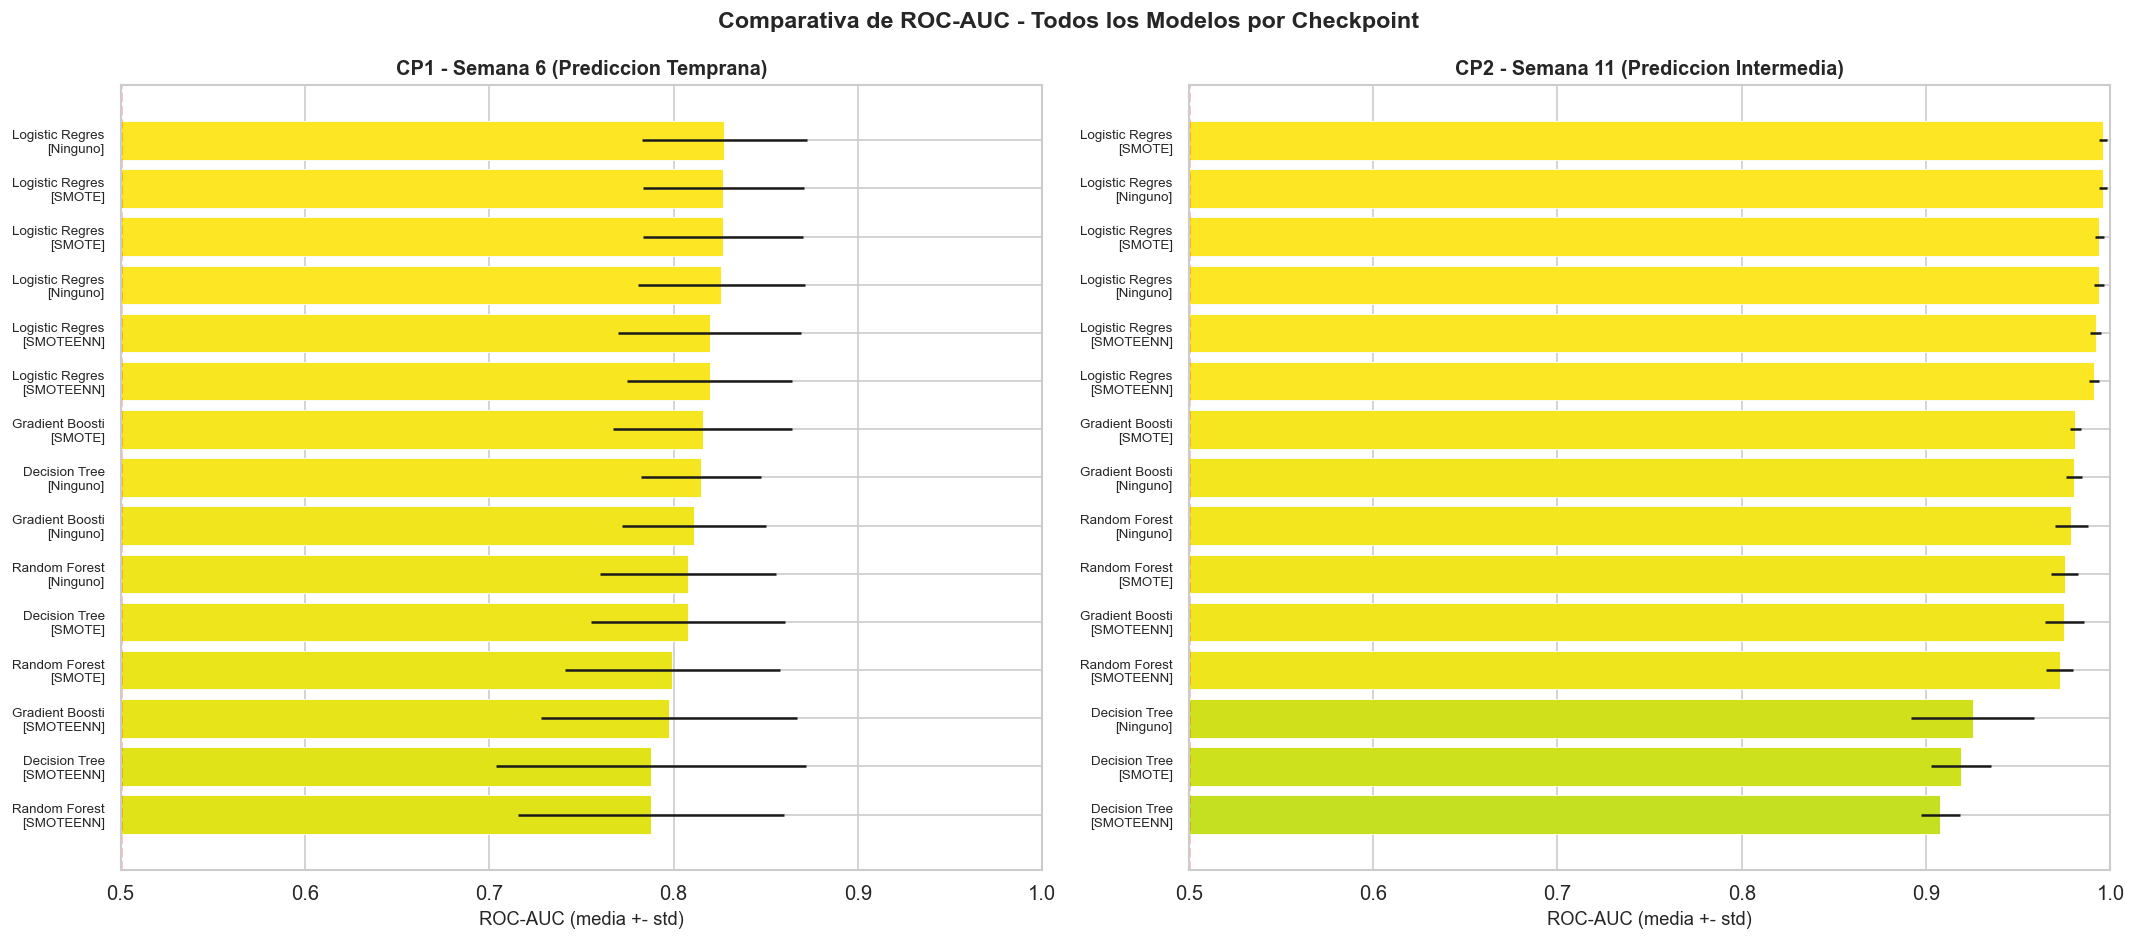

In [12]:
# === Gráfico 1: Comparativa de ROC-AUC ===
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, cp in enumerate(['CP1', 'CP2']):
    cp_data = df_results[df_results['Checkpoint'] == cp].copy()
    cp_data['label'] = cp_data['Modelo'].str[:15] + '\n[' + cp_data['Balanceo'] + ']'
    cp_data = cp_data.sort_values('ROC_AUC_mean', ascending=True)
    
    y_pos = range(len(cp_data))
    
    axes[idx].barh(y_pos, cp_data['ROC_AUC_mean'], 
                   xerr=cp_data['ROC_AUC_std'],
                   color=plt.cm.viridis(cp_data['ROC_AUC_mean'] / cp_data['ROC_AUC_mean'].max()),
                   edgecolor='white', linewidth=0.5)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(cp_data['label'], fontsize=8)
    axes[idx].set_xlabel('ROC-AUC (media +- std)', fontsize=11)
    
    title = "CP1 - Semana 6 (Prediccion Temprana)" if cp == 'CP1' else "CP2 - Semana 11 (Prediccion Intermedia)"
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlim(0.5, 1.0)
    axes[idx].axvline(x=0.5, color='red', linestyle='--', alpha=0.3, label='Azar')

fig.suptitle('Comparativa de ROC-AUC - Todos los Modelos por Checkpoint',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_final_auc.png', dpi=150, bbox_inches='tight')
logger.info("\nGrafico guardado: comparativa_final_auc.png")
plt.show()